<a href="https://colab.research.google.com/github/venkataAshish/Data-Analysis/blob/main/tittanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files
uploaded = files.upload()

file = pd.read_csv("Titanic-Dataset")
print(file)

Saving Titanic-Dataset.csv to Titanic-Dataset.csv
     PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                                  Name     Sex   Age  SibSp  \
0                              Braund, Mr. Owen Harris    male  22.0      1   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                               Heikkinen, Miss. Laina  female  26.0      0   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                             Allen, Mr. William Henry    male  35.0      0   
..                 

In [ ]:
print("FIRST 5 ROWS")
print(file.head())
print("last 5 rows")
print(file.tail())
print("\n DATA SET SHAPE:")
print(file.shape)
print("\n COLUMN NAMES:")
print(file.columns)
print("\nmissing values")
print(file.isnull().sum())
print("\nSTASTICAL SUMMERY: ")
print(file.describe())

FIRST 5 ROWS
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  Unnamed: 12  \
0      0         A/5 21171   7.2500   NaN        S          NaN   
1      0          PC 17599  71.2833   C85        C          NaN   
2      0  STON/O2. 3101282   7.9250   NaN        S          NaN   
3      0            113803  53.1000  C1

eda

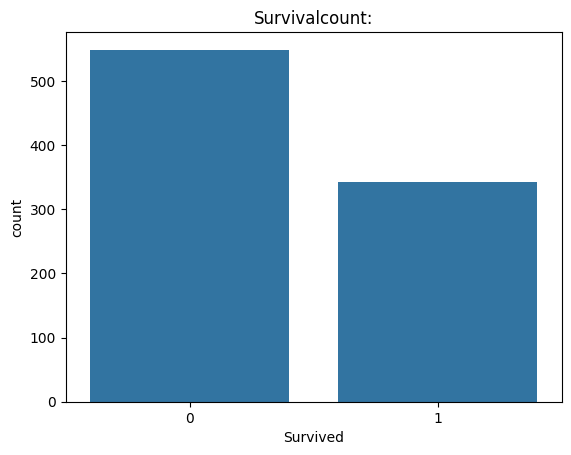

In [ ]:
sns.countplot(x='Survived' , data=file)
plt.title("Survivalcount:")
plt.show()

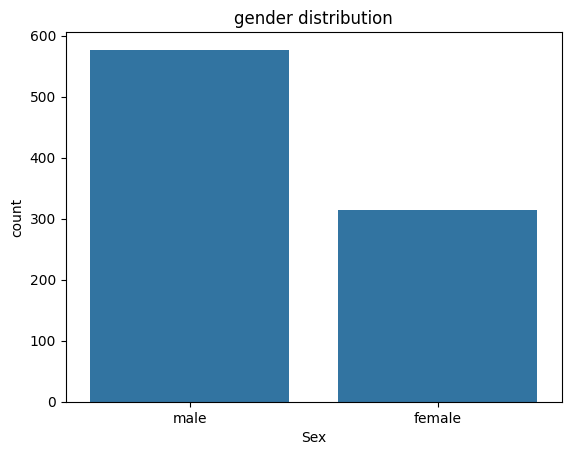

In [ ]:
sns.countplot(x='Sex',data=file)
plt.title("gender distribution")
plt.show()

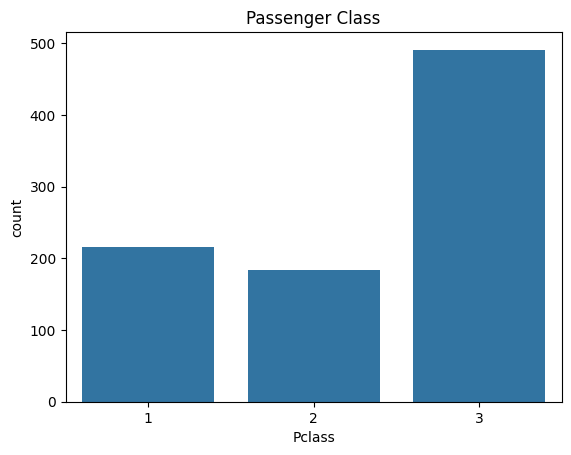

In [ ]:
sns.countplot(x='Pclass', data=file)
plt.title("Passenger Class")
plt.show()

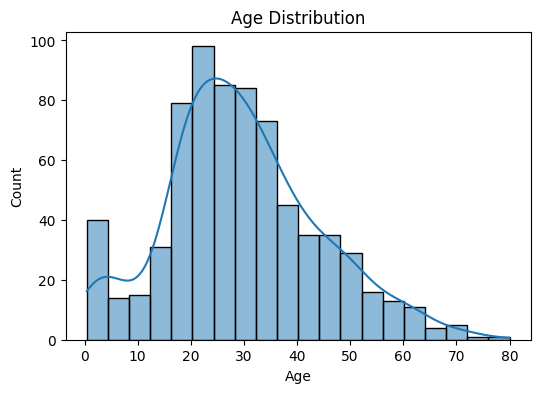

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(file['Age'], bins=20, kde=True)
plt.title("Age Distribution")
plt.show()


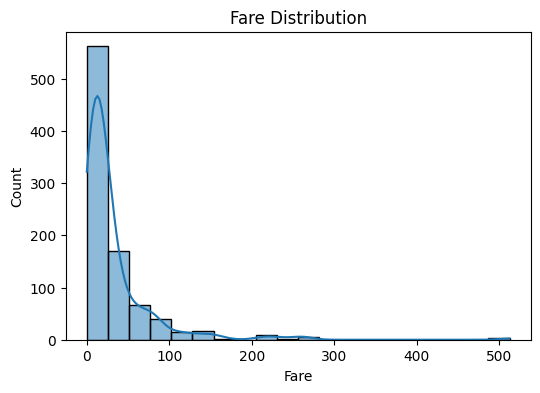

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(file['Fare'], bins=20, kde=True)
plt.title("Fare Distribution")
plt.show()

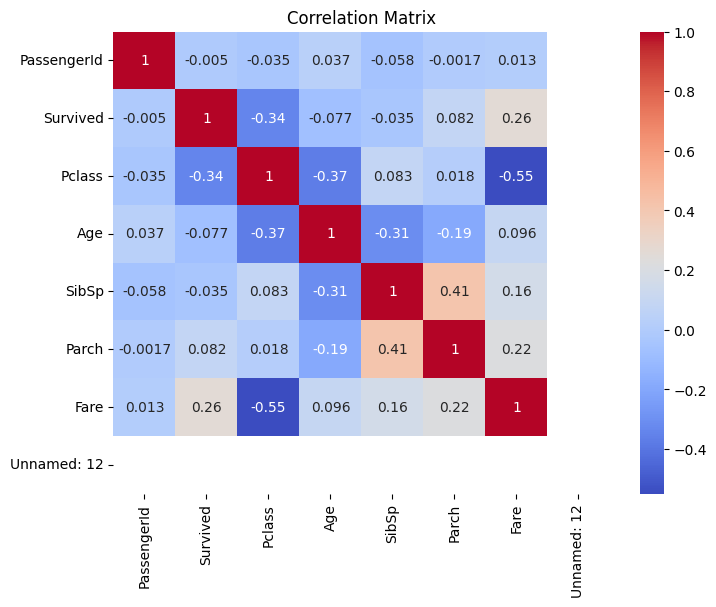

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(file.corr(numeric_only=True),annot=True,cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

Attributes

In [ ]:
print("\nNumeric Attributes")
numeric = file.select_dtypes(include=['int64','float64']).columns
print(numeric)


Numeric Attributes
Index(['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare',
       'Unnamed: 12'],
      dtype='object')


In [ ]:
print("Nominal attributes")
nominal=['Sex','Embarked']
print(nominal)

Nominal attributes
['Sex', 'Embarked']


In [ ]:
print("Binary Attributes")
binary = ['Survived']
print(binary  )

Binary Attributes
['Survived']


Dissimilarity for Nominal Attributes

In [ ]:
sex = file['Sex']
embarked = file['Embarked']

count = 0
total = 0

for s,e in zip(sex,embarked):

    if pd.isna(s) or pd.isna(e):
        continue

    total += 1

    if s != e:
        count += 1

dissimilarity = count/total

print("\nNominal Attribute Dissimilarity")
print("Sex vs Embarked =", dissimilarity)



Nominal Attribute Dissimilarity
Sex vs Embarked = 1.0


Numeric Attribute Dissimilarity


In [ ]:
temp = file[['Age','Fare']].dropna()

age = temp.iloc[0]['Age']
fare = temp.iloc[0]['Fare']

age2 = temp.iloc[1]['Age']
fare2 = temp.iloc[1]['Fare']

distance = np.sqrt((age-age2)**2 + (fare-fare2)**2)

print("\nEuclidean Distance")
print(distance)



Euclidean Distance
66.00199624928021


Manhattan Distance

In [ ]:
manhattan = abs(age-age2)+abs(fare-fare2)

print("\nManhattan Distance")
print(manhattan)


Manhattan Distance
80.0333


In [ ]:
A=np.array([age,fare])
B=np.array([age2,fare2])

cosine_similarity=np.dot(A,B)/(np.linalg.norm(A)*np.linalg.norm(B))

cosine_dissimilarity=1-cosine_similarity

print("\nCosine Dissimilarity")
print(cosine_dissimilarity)


Cosine Dissimilarity
0.2770235351726641
